In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (14, 6)

## EOP Plot

In [2]:
file_path = r"C:\Users\Wasupol\Desktop\Senior_Project_Resource_and_Code\EOP Data\eopc04.1962-now_clean.csv"

df = pd.read_csv(file_path, sep=',')
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df = df[(df['Year'] >= 1990) & (df['Year'] <= 2025)].reset_index(drop=True)

### Polar Motion

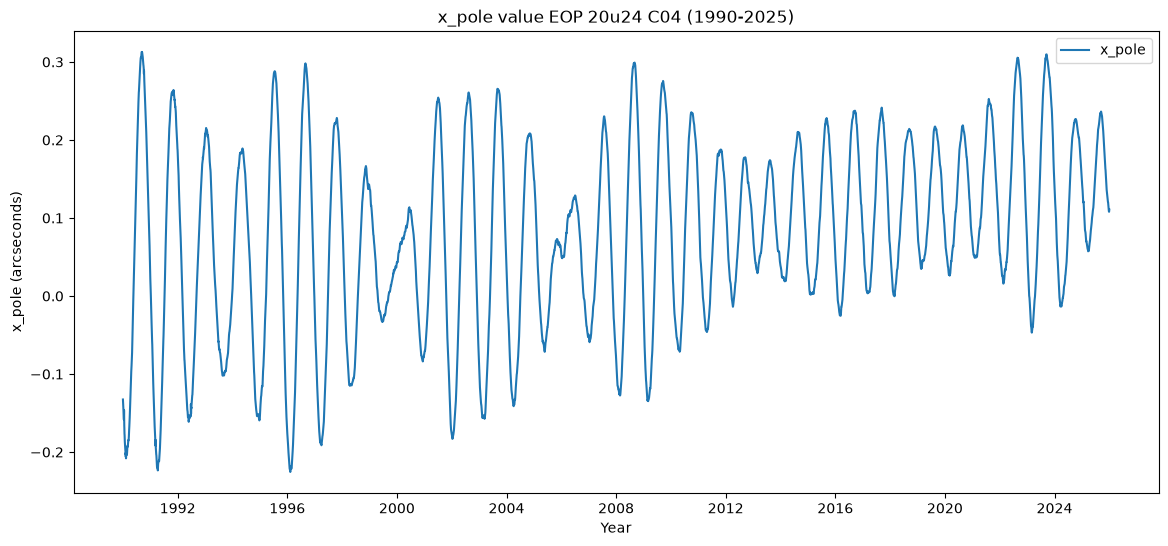

In [3]:
data_x_pole = df[['Date', 'x_pole']].copy()
data_x_pole.set_index('Date', inplace=True)

plt.plot(data_x_pole.index, data_x_pole['x_pole'], label='x_pole')
plt.title('x_pole value EOP 20u24 C04 (1990-2025)')
plt.xlabel('Year')
plt.ylabel('x_pole (arcseconds)')
plt.legend()
plt.show()

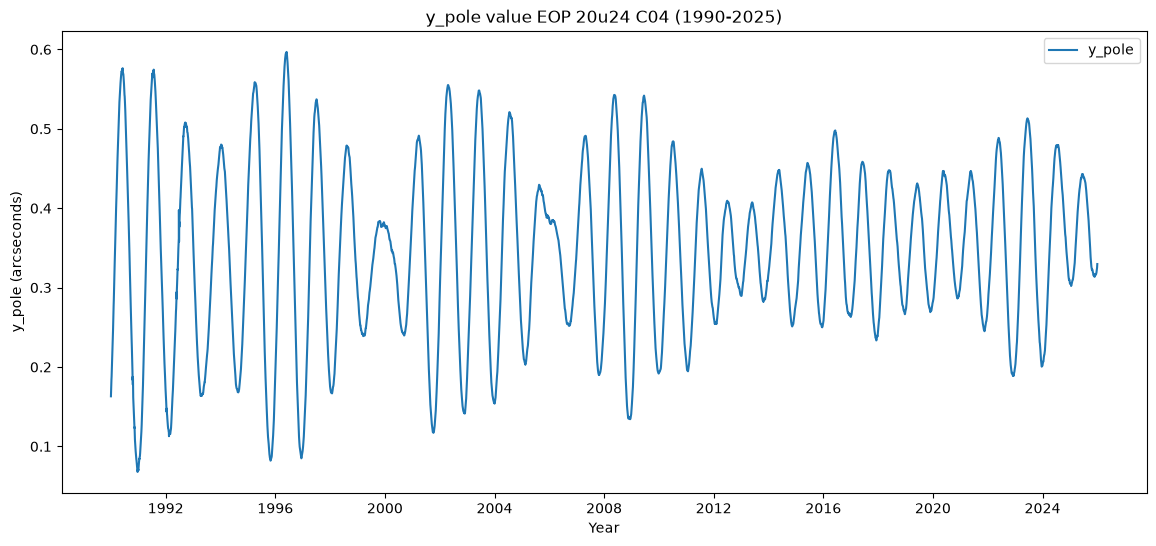

In [4]:
data_y_pole = df[['Date', 'y_pole']].copy()
data_y_pole.set_index('Date', inplace=True)
plt.plot(data_y_pole.index, data_y_pole['y_pole'], label='y_pole')

plt.title('y_pole value EOP 20u24 C04 (1990-2025)')
plt.xlabel('Year')
plt.ylabel('y_pole (arcseconds)')
plt.legend()
plt.show()

### Celestial Pole Offset

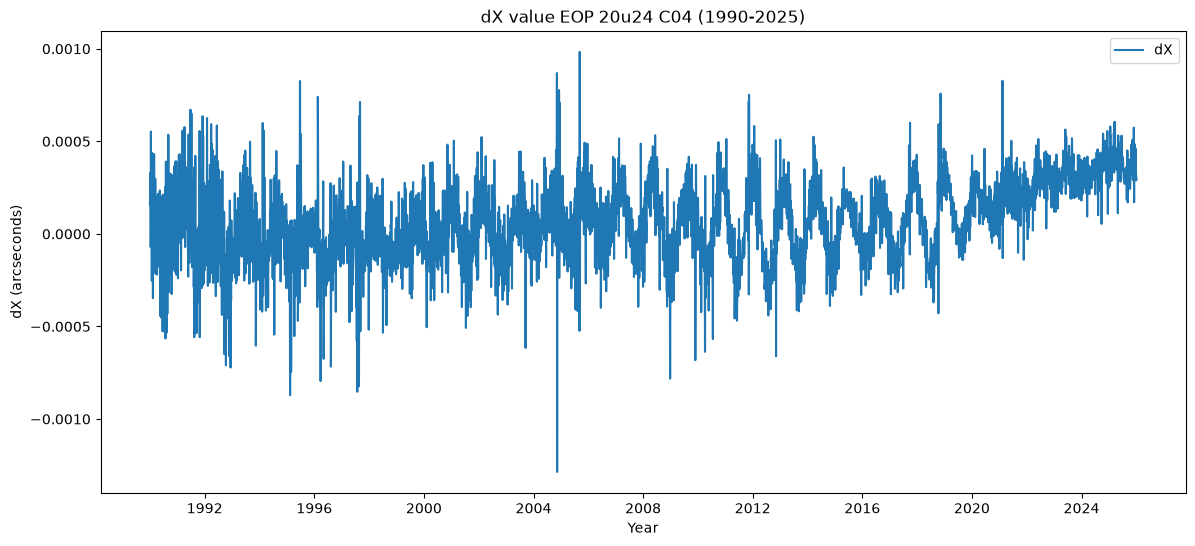

In [5]:
data_dX = df[['Date', 'dX']].copy()
data_dX.set_index('Date', inplace=True)
plt.plot(data_dX.index, data_dX['dX'], label='dX')

plt.title('dX value EOP 20u24 C04 (1990-2025)')
plt.xlabel('Year')
plt.ylabel('dX (arcseconds)')
plt.legend()
plt.show()

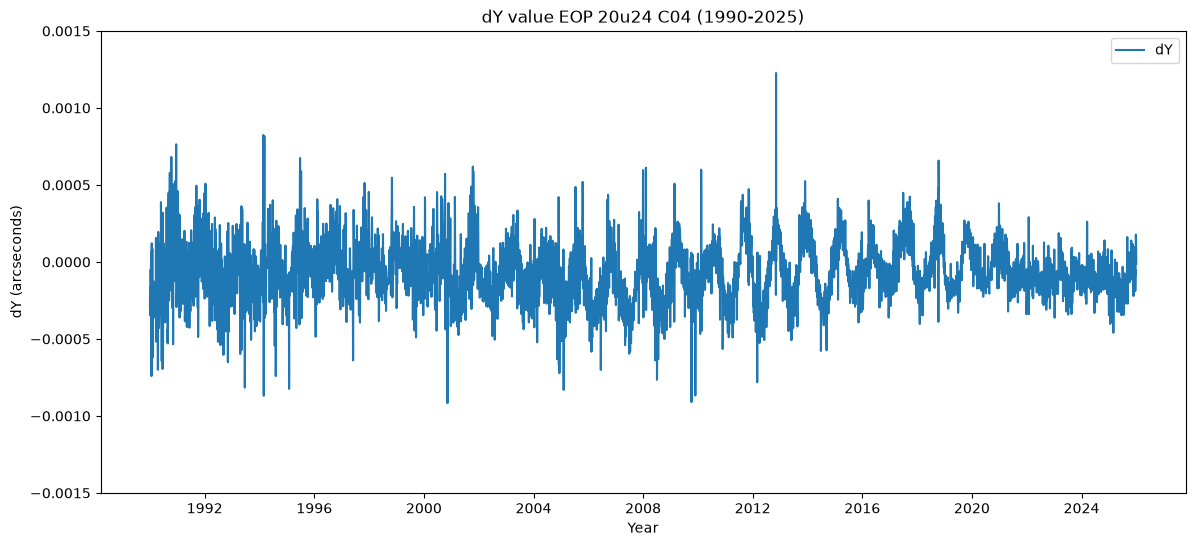

In [6]:
data_dY = df[['Date', 'dY']].copy()
data_dY.set_index('Date', inplace=True)
plt.plot(data_dY.index, data_dY['dY'], label='dY')

plt.title('dY value EOP 20u24 C04 (1990-2025)')
plt.xlabel('Year')
plt.ylabel('dY (arcseconds)')
plt.ylim(-0.0015, 0.0015)
plt.legend()
plt.show()

### Universal Time

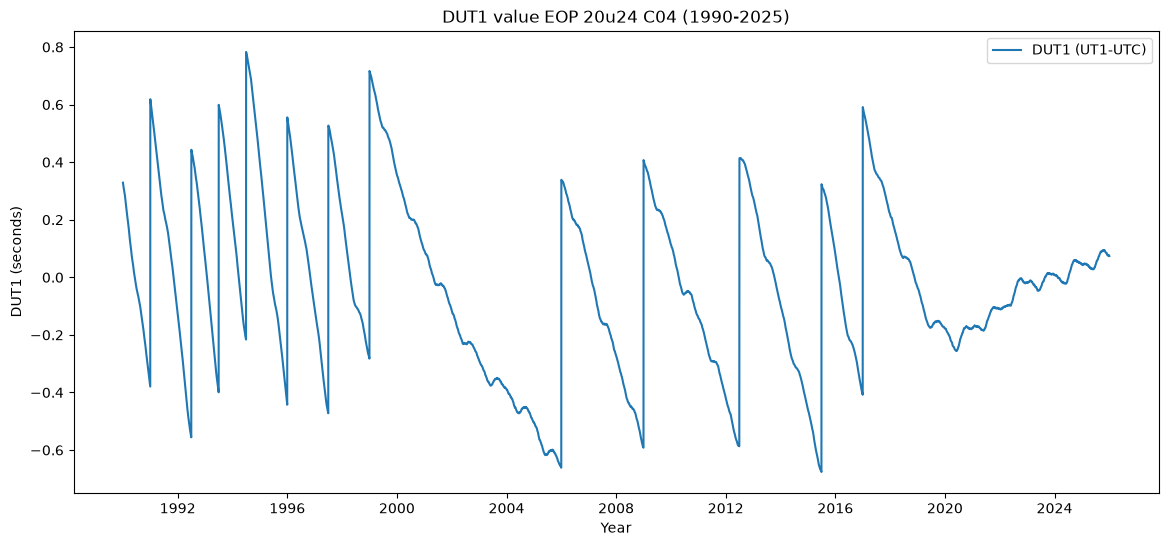

In [7]:
# DUT1 (UT1-UTC)
data_DUT1 = df[['Date', 'UT1-UTC']].copy()
data_DUT1.set_index('Date', inplace=True)
plt.plot(data_DUT1.index, data_DUT1['UT1-UTC'], label='DUT1 (UT1-UTC)')

plt.title('DUT1 value EOP 20u24 C04 (1990-2025)')
plt.xlabel('Year')
plt.ylabel('DUT1 (seconds)')
plt.legend()
plt.show()

### Length of Day (LOD)

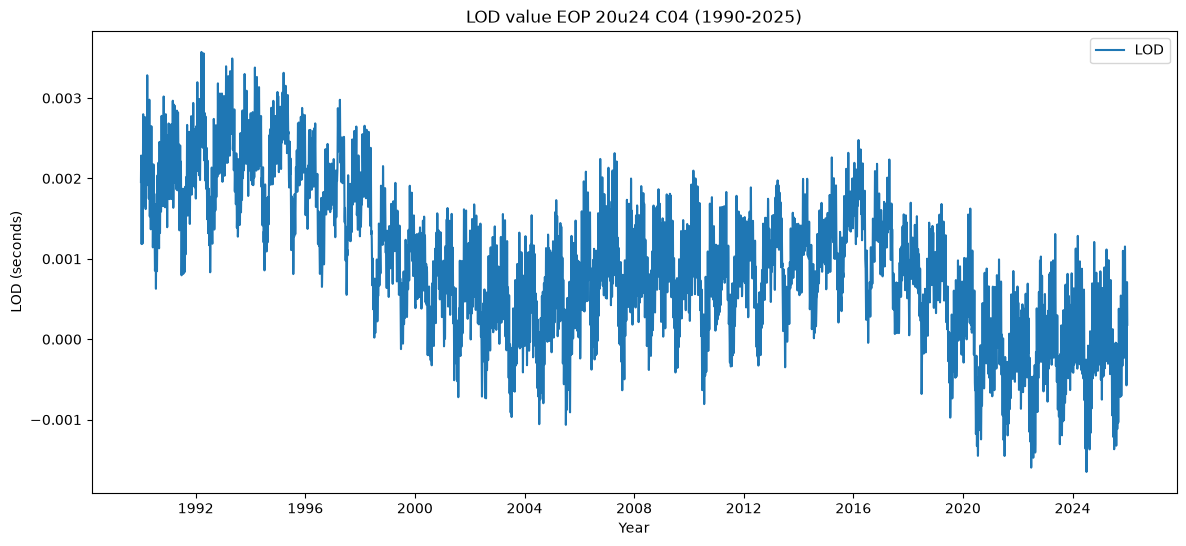

In [8]:
data_LOD = df[['Date', 'LOD']].copy()
data_LOD.set_index('Date', inplace=True)
plt.plot(data_LOD.index, data_LOD['LOD'], label='LOD')

plt.title('LOD value EOP 20u24 C04 (1990-2025)')
plt.xlabel('Year')
plt.ylabel('LOD (seconds)')
plt.legend()
plt.show()

## Data Preparation

In [11]:
scalar = MinMaxScaler(feature_range=(0, 1))
scaled_data = scalar.fit_transform(data_x_pole)

train_size = int(len(scaled_data) * 0.8)
val_size = int(len(scaled_data) * 0.1)
test_size = len(scaled_data) - train_size - val_size

train_data = scaled_data[:train_size]
val_data = scaled_data[train_size:train_size + val_size]
test_data = scaled_data[train_size + val_size:]

print(f"Train size: {len(train_data)}, Validation size: {len(val_data)}, Test size: {len(test_data)}")


Train size: 10519, Validation size: 1314, Test size: 1316


In [ ]:
def create_sequences(dataset, look_back = 30):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 30

X_train, y_train = create_sequences(train_data, look_back)
X_val, y_val = create_sequences(val_data, look_back)
X_test, y_test = create_sequences(test_data, look_back)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

## LSTM Model

Epoch 1/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0085 - val_loss: 3.1806e-04
Epoch 2/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0024 - val_loss: 4.7072e-04
Epoch 3/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0016 - val_loss: 2.6726e-04
Epoch 4/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0011 - val_loss: 4.2348e-05
Epoch 5/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.3671e-04 - val_loss: 3.1771e-05
Epoch 6/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.0145e-04 - val_loss: 1.0612e-04
Epoch 7/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.1755e-04 - val_loss: 2.4271e-05
Epoch 8/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.7996e-04 - val_loss: 2.5260e-05
Epoch 9/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.4701e-04 - val_loss: 3.2383e-05
Epoch 10/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.0439e-04 - val_loss: 4.8919e-05
Epoch 11/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.79

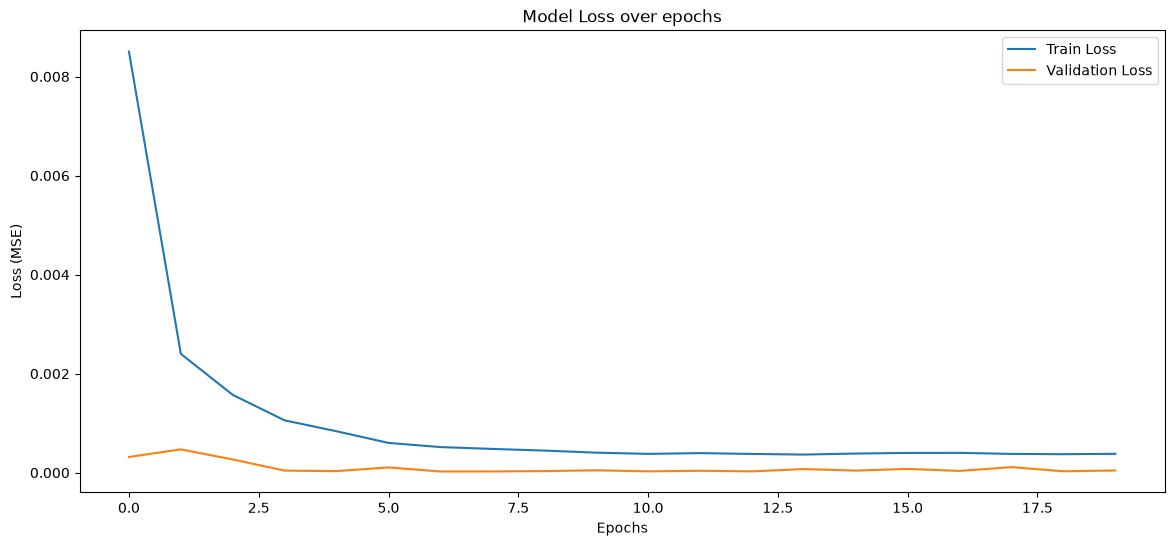

In [15]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, batch_size=64, epochs=20, validation_data=(X_val, y_val), verbose=1)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


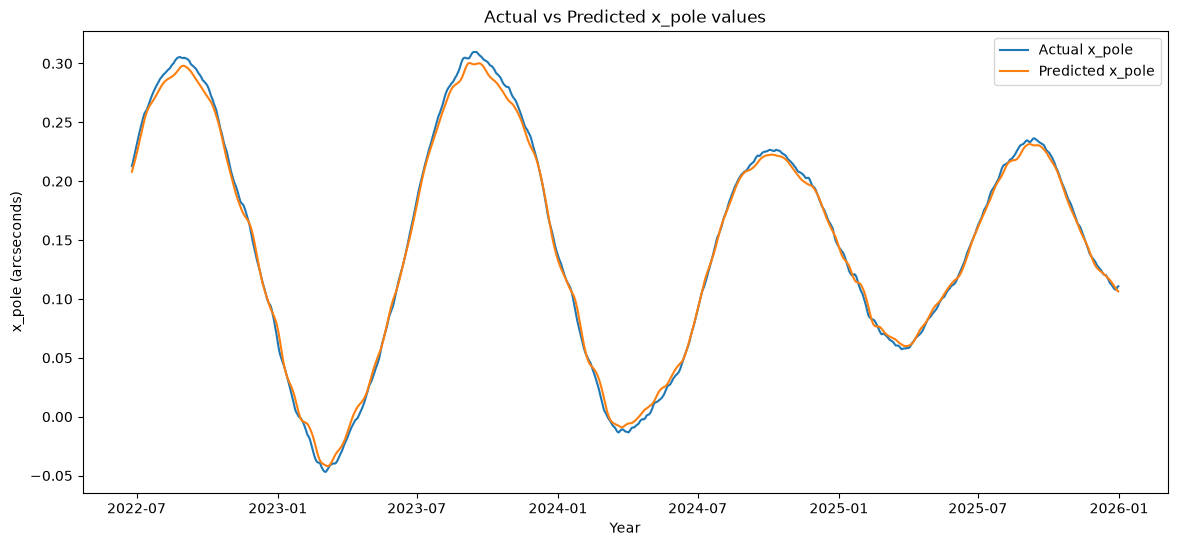

In [16]:
predictions = model.predict(X_test)
predictions = scalar.inverse_transform(predictions)
y_test_inverse = scalar.inverse_transform(y_test.reshape(-1, 1))

test_dates = df['Date'].values[train_size + val_size + look_back:]

plt.plot(test_dates, y_test_inverse, label='Actual x_pole')
plt.plot(test_dates, predictions, label='Predicted x_pole')
plt.title('Actual vs Predicted x_pole values')
plt.xlabel('Year')
plt.ylabel('x_pole (arcseconds)')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_inverse, predictions)
print(f"Mean Absolute Error (MAE) on test set: {mae}")

Mean Absolute Error (MAE) on test set: 0.004068570631488674


### Chronos-2 (Try)